In [1]:
import sys
import importlib
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

sys.path.append("/Users/arthurbenard/Project 1B/src")

import pandas as pd
import numpy as np
import xgboost

In [2]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, learning_curve, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [ ]:
# Force Jupyter to reload the module from the hard drive
import data_converter.hplc_data_handler
importlib.reload(data_converter.hplc_data_handler)

# Now do the specific imports
from data_converter.hplc_data_handler import cleaning_array_by_cas, NMR_SOLVENTS, smiles_to_fingerprint, scrub, compress_fingerprints_pca, calculate_descriptors
from controller.predictor_runner import generate_ml_ready_file_fingerprint_solvent, generate_ml_ready_file_onehot_solvent, generate_ml_file_with_logs, solubility_file_matrix, add_logs_to_df, add_matrix_id_to_df, run_descriptor_competition, run_hyperparameter_competition
from analysis.analysis import run_ablation_study, plot_comparison, run_data_fraction, plot_learning_curve, run_ablation_xgboost, learning_curve_trainsize_kselectors

sklearn only speaks "math", therefore SMILES needs to be translated (Morgan Fingerprint that acts as barcode)
created smiles_to_fingerprints in hplc_data_handler

we'll first clean the smiles file + raw data, removing duplicates and 0 signals

In [2]:
csv_file = '/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.csv'
df_csv = pd.read_csv(csv_file)


excel_file = '/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx'
df_csv.to_excel(excel_file, index=False)

cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------



solvents also need to be converted to numbers, we'll just get the SMILES and then call the same function smiles_to_fingerprint. the df generated below is only for one solvent given, that way its size is approximately 4 x ~150

This cell is for *MeOH*.

In [ ]:
ml_df = generate_ml_ready_file_fingerprint_solvent(cleaned_df, 'MeOH', NMR_SOLVENTS, smiles_to_fingerprint)

[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerat

This cell is for *ACN*.

In [ ]:
ml_df = generate_ml_ready_file_fingerprint_solvent(cleaned_df, 'ACN', NMR_SOLVENTS, smiles_to_fingerprint)

these are commands to verify it worked

In [4]:
print(ml_df.head())
print(f"\nShape: {ml_df.shape}")

                                  Sample Fingerprint     RT  \
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  5.607   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  1.146   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  4.021   
3  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  3.327   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  5.678   

                                             Solvent  Soluble  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        1  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  

Shape: (144, 4)


let's write a simple model, the **baseline model**. RandomForest is recommended for its ability to handle high dimensions perfectly (our fingerprints generated a lot of 'bits', more rows than columns), handle non-linear data. it is also apparently less prone to overfitting. a good combination of high accuracy, resistance to overfitting, and the ability to easily explain your results. plus we don't have a lot of data... i think it's good to start with this, even though i've read that it isn't very efficient when it comes to predict outside of "what it's seen"

Machine learning models hate hidden arrays. They want one massive, flat 2D grid (like a giant Excel sheet) where every single bit gets its own dedicated column. This means our df content needs to be flattened. *np.vstack* takes those individual arrays out of the Pandas cells and stacks them vertically on top of each other.

In [6]:
X_solute = np.vstack(ml_df['Sample Fingerprint'].values)  
X_solvent = np.vstack(ml_df['Solvent'].values)

# reshaping is necessary, because X_solute is a 2D grid, and when we'll need to glue it back to 'RT' there's going to be a conflict of dimensions (1D vs 2D). 
# so .reshape turns 'RT' in a column of 2D
X_rt = ml_df['RT'].values.reshape(-1, 1)

# glue back together, assign X and y
X = np.hstack((X_solute, X_rt, X_solvent))
y = ml_df['Soluble'].values

print(f"Final X matrix shape: {X.shape}")
print(f"Final y vector shape: {y.shape}")

Final X matrix shape: (144, 4097)
Final y vector shape: (144,)


This is the splitting data set: 70% for training, 20% for validation and 10% for testing

In [ ]:
# Cuts off 30% of the data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Split that 30% into what is needed
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")


--- Split Complete ---
Training Set:   100 rows (70%)
Validation Set: 29 rows (20%)
Testing Set:    15 rows (10%)


this is the training cell for **Baseline Model**

In [ ]:
# training the Baseline Random Forest ONLY on the training Set
print("Training the Baseline Model ...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=75, n_jobs=-1, class_weight='balanced')
rf_baseline.fit(X_train, y_train)

Training the Baseline Model ...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Validation step for **Baseline Model**, printing out results too

In [15]:
predictions_val = rf_baseline.predict(X_val)

print("\n==============================================")
print("  BASELINE MODEL EXAM RESULTS (VALIDATION SET)")
print("==============================================")
print(classification_report(y_val, predictions_val)) #this will give an idea of the accuracy


  BASELINE MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.30      0.33      0.32         9
           1       0.68      0.65      0.67        20

    accuracy                           0.55        29
   macro avg       0.49      0.49      0.49        29
weighted avg       0.56      0.55      0.56        29



Confusion Matrix: the Top-Left box is how many insoluble molecules it successfully caught, the Bottom-Right box is how many soluble molecules it successfully identified.

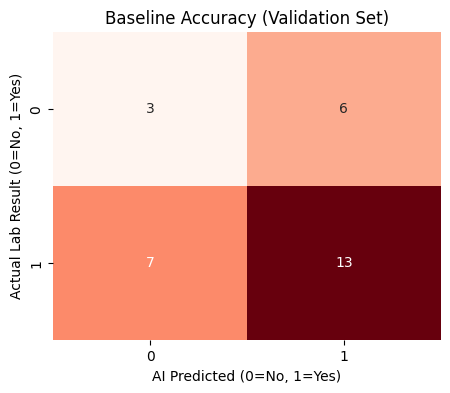

In [16]:
# plotting Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_val, predictions_val), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Baseline Accuracy (Validation Set)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

This is a code given by Gemini to 'map' what characteristics were most used in the validation. This may be useful when adding new descriptors.

/var/folders/hp/w678cy2j2fvf_gn9ys7fr_r00000gn/T/ipykernel_95704/1510073726.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Importance', y='Feature', palette='viridis')


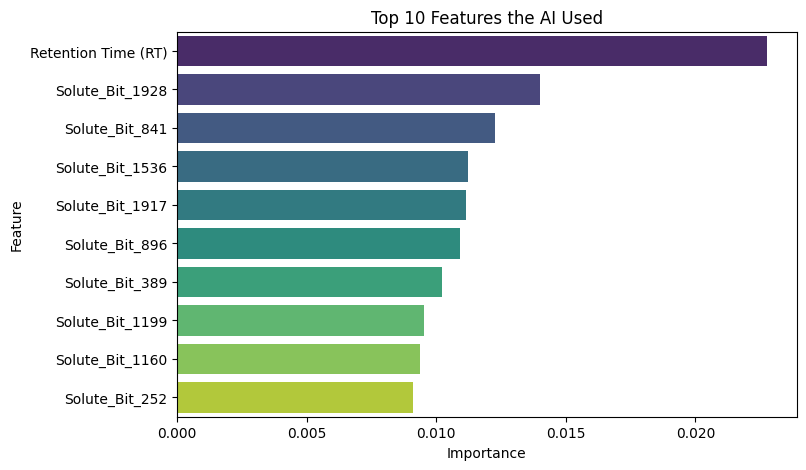

In [17]:
# Get the importance scores
importances = rf_baseline.feature_importances_

# Recreate the column names so we know what they are
solute_names = [f"Solute_Bit_{i}" for i in range(2048)]
rt_name = ["Retention Time (RT)"]
solvent_names = [f"Solvent_Bit_{i}" for i in range(2048)]
feature_names = solute_names + rt_name + solvent_names

# Create a DataFrame and sort it
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10 = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot it
plt.figure(figsize=(8, 5))
sns.barplot(data=top_10, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Features the AI Used')
plt.show()

Now this is only using one of the solvents available in the dictionary, this will be an attempt at introducing the model to new solvents.

In [2]:
cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------


In [3]:
print("Gathering data for all solvents...")
all_dfs = []
solvents_list = list(NMR_SOLVENTS.keys())

# looping on all solvents
for sol in solvents_list:
    if sol in cleaned_df.columns:
        df_temp = generate_ml_ready_file_fingerprint_solvent(cleaned_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs.append(df_temp)
        print(f" - {sol}: added {len(df_temp)} experiments.")


# .concat function that takes a list of separate DataFrames and smashes them on top of each other into one giant DataFrame
mega_df = pd.concat(all_dfs, ignore_index=True)
print(f"MEGA DATAFRAME CREATED: {len(mega_df)} TOTAL ROWS\n")



Gathering data for all solvents...


[10:59:22] DEPRECATION WARNING: please use MorganGenerator
[10:59:22] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerat

 - MeOH: added 144 experiments.


[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerat

 - ACN: added 144 experiments.


[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerat

 - DMSO: added 144 experiments.


[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerat

 - DCM: added 144 experiments.


[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerat

 - CHCl3: added 144 experiments.
MEGA DATAFRAME CREATED: 720 TOTAL ROWS



[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerat

This cell is different, to uncover if the Morgan fingerprint actually hinders the accuracy the solvents will be coded differently: ***one-hot coded*** to be precise. It just means that for 5 solvents we'll make 5 independent codes. We suspect that somes solvents have too similar fingerprints....

In [8]:
print("Gathering data for all solvents...")
all_dfs = []
solvents_list = list(NMR_SOLVENTS.keys())

# looping on all solvents
for sol in solvents_list:
    if sol in cleaned_df.columns:
        df_temp = generate_ml_ready_file_onehot_solvent(cleaned_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs.append(df_temp)
        print(f" - {sol}: added {len(df_temp)} experiments.")


# .concat function that takes a list of separate DataFrames and smashes them on top of each other into one giant DataFrame
mega_df = pd.concat(all_dfs, ignore_index=True)
print(f"MEGA DATAFRAME CREATED: {len(mega_df)} TOTAL ROWS\n")

Gathering data for all solvents...


[16:05:45] DEPRECATION WARNING: please use MorganGenerator
[16:05:45] DEPRECATION WARNING: please use MorganGenerator
[16:05:45] DEPRECATION WARNING: please use MorganGenerator
[16:05:45] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerat

 - MeOH: added 144 experiments.


[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerat

 - ACN: added 144 experiments.


[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerat

 - DMSO: added 144 experiments.


[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerat

 - DCM: added 144 experiments.


[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerat

 - CHCl3: added 144 experiments.
MEGA DATAFRAME CREATED: 720 TOTAL ROWS



[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator


In [14]:
print(mega_df['Solvent'].iloc[500])

[0 0 0 1 0]


In [15]:
X_solute = np.vstack(mega_df['Sample Fingerprint'].values)  
X_rt = mega_df['RT'].values.reshape(-1, 1)           
X_solvent = np.vstack(mega_df['Solvent'].values)     

X = np.hstack((X_solute, X_rt, X_solvent))
y = mega_df['Soluble'].values
groups = mega_df['SMILES'].values # Why SMILES? it's to prevent a potential problem, when model will randomly select data as training it might not see that there's mol for MEOH and ACn and DMSO...
                                # this can falsify the precision of the model because it will not differentiate the solvents (it's not learning chemistry). SO by adding SMILES, we tell the code that
                                # if he encounters several similar SMILES to take them all into account in the training, that way in knows there's a difference between solvents.  
                                # generate_ml_ready_filehas been modified for this purpose.

In [16]:
print("Splitting data safely by Molecule...")

# splitting of the data in same proportions as before, GroupShuffleSplit model needed to shuffle as explained before
# first take out the 30% and keep training set
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups))

X_train, y_train, groups_temp = X[train_idx], y[train_idx], groups[temp_idx]
X_temp, y_temp = X[temp_idx], y[temp_idx]

# then separate validation and testing
gss2 = GroupShuffleSplit(n_splits=1, test_size=(1/3), random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")

Splitting data safely by Molecule...

--- Split Complete ---
Training Set:   500 rows (70%)
Validation Set: 145 rows (20%)
Testing Set:    75 rows (10%)


In [17]:
rf_mega = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mega.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_val_pred = rf_mega.predict(X_val)

print("=========================================")
print("  MEGA MODEL EXAM RESULTS (VALIDATION SET)")
print("=========================================")
print(classification_report(y_val, y_val_pred))

  MEGA MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.61      0.20      0.31        54
           1       0.66      0.92      0.77        91

    accuracy                           0.66       145
   macro avg       0.64      0.56      0.54       145
weighted avg       0.64      0.66      0.60       145



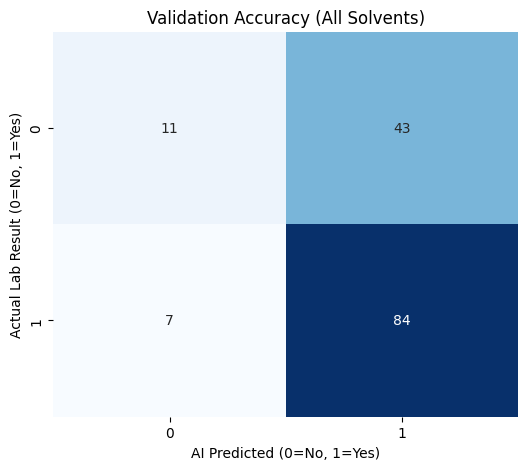

In [19]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Validation Accuracy (All Solvents)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

A 1% increase in accuracy has been observed, not much but something at least... Let's add a new parameter to train on and analyze the outcome: **predicted logS** from Fastsolv. New function has been made in predictor_runner

First, we need to prepare the cleaned_df, make sure the predicted logS is in it (we've been working without it for a while).

In [2]:
cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')
# recalculating solubility
"""sol_matrix = solubility_file_matrix(cleaned_df, NMR_SOLVENTS)"""
sol_matrix= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------


In [3]:
final_working_df = add_logs_to_df(cleaned_df, sol_matrix, NMR_SOLVENTS)

Successfully added 5 exact logS columns


In [4]:
print(final_working_df.columns.tolist())

['Column', 'Method', 'Sample Name', 'CAS ', 'RT', 'Signal', 'Matrix ID Name', 'MeOH', 'ACN', 'DMSO', 'DCM', 'CHCl3', 'solute_smiles', 'predicted_logS_MeOH', 'predicted_logS_ACN', 'predicted_logS_DMSO', 'predicted_logS_DCM', 'predicted_logS_CHCl3']


In [4]:
print("Gathering data for all solvents...")
all_dfs_v3 = []

for sol in NMR_SOLVENTS.keys():
    # since we are using cleaned_df, we just look for 'MeOH', 'ACN', etc.
    if sol in cleaned_df.columns:
        df_temp = generate_ml_file_with_logs(final_working_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs_v3.append(df_temp)
        print(f"Added {sol}: {len(df_temp)} rows")
    else:
        print(f"Skipped {sol}: Column not found")

# sticking everything together
mega_df_v3 = pd.concat(all_dfs_v3, ignore_index=True)
print(f"DataFrame built! Total Rows: {len(mega_df_v3)}")

Gathering data for all solvents...


[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerator
[10:07:24] DEPRECATION WARNING: please use MorganGenerat

Added MeOH: 144 rows


[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerator
[10:07:25] DEPRECATION WARNING: please use MorganGenerat

Added ACN: 144 rows


[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerator
[10:07:26] DEPRECATION WARNING: please use MorganGenerat

Added DMSO: 144 rows


[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerator
[10:07:27] DEPRECATION WARNING: please use MorganGenerat

Added DCM: 144 rows


[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerat

Added CHCl3: 144 rows
DataFrame built! Total Rows: 720


[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator


Some code to check if it was built correctly.

In [6]:
# 1. Check the overall shape and data types
print(f"Total Shape: {mega_df_v3.shape[0]} rows, {mega_df_v3.shape[1]} columns\n")
print("--- Data Types & Non-Null Counts ---")
print(mega_df_v3.info())

# 2. Check for any sneaky missing values
print("\n--- Missing Values ---")
print(mega_df_v3.isnull().sum())

# 3. Verify the 'Soluble' target is strictly 0s and 1s
print(f"\n--- Unique values in 'Soluble' column ---")
print(mega_df_v3['Soluble'].unique())

# 4. Verify the One-Hot array length (should be 5 if you have 5 solvents)
sample_array = mega_df_v3['Solvent'].iloc[0]
print(f"\n--- One-Hot Array Check ---")
print(f"Sample array: {sample_array}")
print(f"Array length: {len(sample_array)}")

# 5. Take a peek at the actual data (focusing on our new logS column!)
print("\n--- First 3 Rows ---")
display(mega_df_v3[['SMILES', 'RT', 'logS', 'Solvent', 'Soluble']].head(3))

print(mega_df_v3[['logS','Solvent']].iloc[145])

Total Shape: 720 rows, 6 columns

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sample Fingerprint  720 non-null    object 
 1   RT                  720 non-null    float64
 2   logS                720 non-null    float64
 3   Solvent             720 non-null    object 
 4   Soluble             720 non-null    int64  
 5   SMILES              720 non-null    str    
dtypes: float64(2), int64(1), object(2), str(1)
memory usage: 57.1+ KB
None

--- Missing Values ---
Sample Fingerprint    0
RT                    0
logS                  0
Solvent               0
Soluble               0
SMILES                0
dtype: int64

--- Unique values in 'Soluble' column ---
[1 0]

--- One-Hot Array Check ---
Sample array: [1 0 0 0 0]
Array length: 5

--- First 3 Rows ---


,SMILES,RT,logS,Solvent,Soluble
0,CC(C1=CC=CC=C1)Br,5.607,0.594901,"[1, 0, 0, 0, 0]",1
1,C1C(CC(=O)NC1=O)CC(=O)O,1.146,-0.160339,"[1, 0, 0, 0, 0]",0
2,C1=CC=C(C=C1)COC(=O)NCC(=O)NCC(=O)O,4.021,-1.251555,"[1, 0, 0, 0, 0]",0


logS             -1.425989
Solvent    [0, 1, 0, 0, 0]
Name: 145, dtype: object


In [6]:
print("Unique values in the 'Soluble' column:")
print(mega_df_v3['Soluble'].value_counts(dropna=False))

Unique values in the 'Soluble' column:
Soluble
1    473
0    247
Name: count, dtype: int64


In [5]:
X_solute = np.vstack(mega_df_v3['Sample Fingerprint'].values)  
X_rt     = mega_df_v3['RT'].values.reshape(-1, 1)    
X_logs   = mega_df_v3['logS'].values.reshape(-1, 1)  # NEW reshaping like above line
X_solvent= np.vstack(mega_df_v3['Solvent'].values)

X_v3 = np.hstack((X_solute, X_rt, X_logs, X_solvent))
y_v3 = mega_df_v3['Soluble'].values
groups_v3 = mega_df_v3['SMILES'].values

print(f" Final matrix shape: {X_v3.shape}")

 Final matrix shape: (720, 2055)


Now that the final matrix is done, let's train.

In [6]:
print("Splitting data safely by Molecule...")

# splitting of the data in same proportions as before, GroupShuffleSplit model needed to shuffle as explained before
# first take out the 30% and keep training set
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X_v3, y_v3, groups_v3))

X_train, y_train, groups_temp = X_v3[train_idx], y_v3[train_idx], groups_v3[temp_idx]
X_temp, y_temp = X_v3[temp_idx], y_v3[temp_idx]

# then separate validation and testing
gss2 = GroupShuffleSplit(n_splits=1, test_size=(1/3), random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")

Splitting data safely by Molecule...

--- Split Complete ---
Training Set:   500 rows (70%)
Validation Set: 145 rows (20%)
Testing Set:    75 rows (10%)


In [10]:
rf_mega = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mega.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
y_val_pred = rf_mega.predict(X_val)

print("=========================================")
print("  V3 MEGA MODEL EXAM RESULTS (VALIDATION SET)")
print("=========================================")
print(classification_report(y_val, y_val_pred))

  V3 MEGA MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.80      0.37      0.51        54
           1       0.72      0.95      0.82        91

    accuracy                           0.73       145
   macro avg       0.76      0.66      0.66       145
weighted avg       0.75      0.73      0.70       145



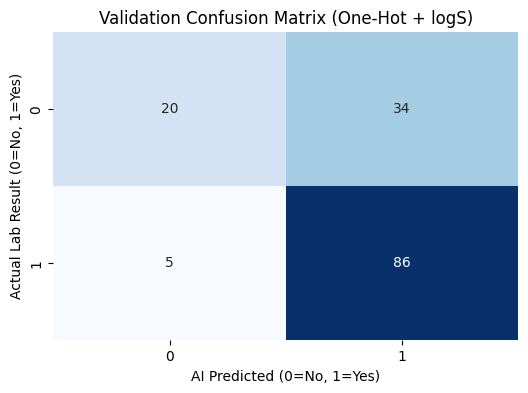

In [12]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Validation Confusion Matrix (One-Hot + logS)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

This cell right under is part of the 'removing features from model' function I wrote. I'm testing out different things and saving them in files (removing ***A*** feature then removing ***SOME*** features).

In [12]:
df_results = run_ablation_study(mega_df_v3)

  AVAILABLE FEATURES TO REMOVE:
  - Sample Fingerprint
  - RT
  - logS
  - Solvent
  - None (Keep all features)

Removing [Sample Fingerprint] from model...
Matrix shape after removal: (720, 7)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_Sample_Fingerprint.txt




Removing [None] from model...
Matrix shape after removal: (720, 2055)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_None.txt


Removing [RT] from model...
Matrix shape after removal: (720, 2054)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_RT.txt


Removing [logS] from model...
Matrix shape after removal: (720, 2054)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_logS.txt


Removing [RT, logS] from model...
Matrix shape after removal: (720, 2055)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_RT,_logS.txt


Removing [Sample Fingerprint] from model...
Matrix shape after removal: (720, 7)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_Sample_Fingerprint.txt


Removing [Sampl

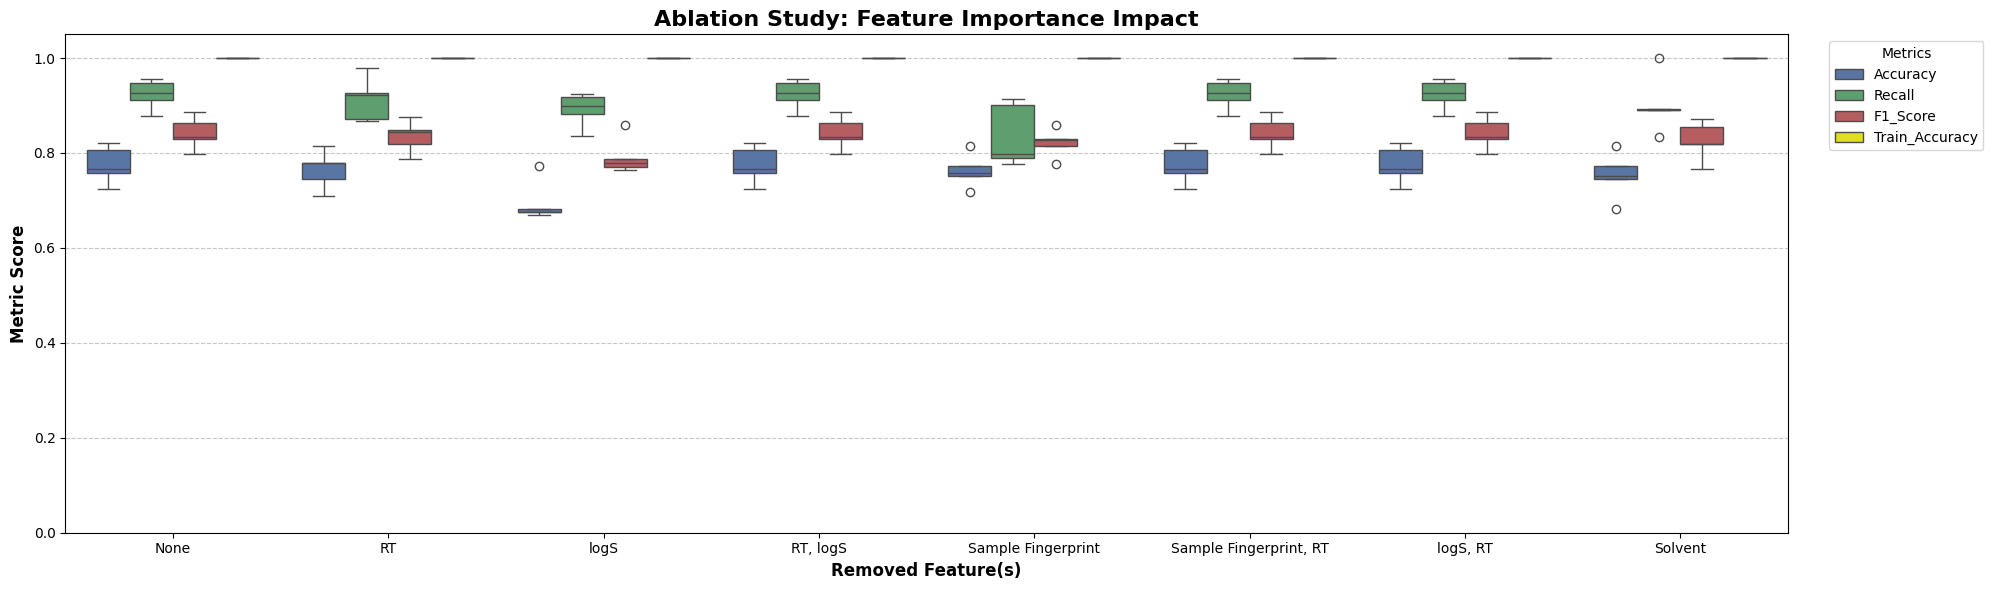

In [5]:
df_none = run_ablation_study(mega_df_v3, features_to_remove='None')
df_rt = run_ablation_study(mega_df_v3, features_to_remove='RT')
df_logs = run_ablation_study(mega_df_v3, features_to_remove='logS')
df_both = run_ablation_study(mega_df_v3, features_to_remove='RT, logS')
df_fp = run_ablation_study(mega_df_v3, features_to_remove='Sample Fingerprint')
df_fp_rt = run_ablation_study(mega_df_v3, features_to_remove='Sample Fingerprint, RT')
df_fp_logs = run_ablation_study(mega_df_v3, features_to_remove='logS, RT')
df_sol = run_ablation_study(mega_df_v3, features_to_remove='Solvent')

# Glue them together into one massive DataFrame
all_results_df = pd.concat([df_none, df_rt, df_logs, df_both, df_fp, df_fp_rt, df_fp_logs, df_sol], ignore_index=True)

plot_comparison(all_results_df)

In [6]:
print(all_results_df.columns)

Index(['Removed_Feature', 'Seed', 'Train_Accuracy', 'Accuracy', 'Precision',
       'Recall', 'F1_Score'],
      dtype='str')


Leander recommended we try to plot a "learning curve" of the model. This means starting with a small sample to train on and increasing until we reach 70%. I'm going to write a function that has a loop which modifies which section of the data to take in, and returns a .txt file. Then we'll worry about the plot.

let's try with 10% of training

In [5]:
run_data_fraction(mega_df_v3, 0.1 )


Running Learning Curve Step: 10% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_10pct.txt


,Train_Size_Pct,Seed,Train_Accuracy,Val_Accuracy,Test_Accuracy,Precision,Recall,F1_Score
0,10,42,1.0,0.634884,0.663636,0.800000,0.613139,0.694215
1,10,93,1.0,0.637209,0.713636,0.740331,0.893333,0.809668
2,10,123,1.0,0.688372,0.672727,0.666667,0.978723,0.793103
3,10,2024,1.0,0.676744,0.700000,0.697115,0.979730,0.814607
4,10,777,1.0,0.737209,0.645455,0.773109,0.643357,0.702290


let's loop this now to increase the set all the way to 70%

In [5]:
percentages_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
all_learning_curve_results = []

for pct in percentages_to_test:
    # Call the function we just built
    df_step = run_data_fraction(mega_df_v3, train_percent_of_total=pct)
    
    # Add the results to our list
    all_learning_curve_results.append(df_step)

# Glue everything together into one master DataFrame for plotting later
master_lc_df = pd.concat(all_learning_curve_results, ignore_index=True)

print("\nAll learning curve steps complete and concatenated")


Running Learning Curve Step: 10% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_10pct.txt

Running Learning Curve Step: 20% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_20pct.txt

Running Learning Curve Step: 30% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_30pct.txt

Running Learning Curve Step: 40% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_40pct.txt

Running Learning Curve Step: 50% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_50pct.txt

Running Learning Curve Step: 60% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_cur

Generating Learning Curve Plot...
-> Plot successfully saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/Learning_Curve_Plot.png


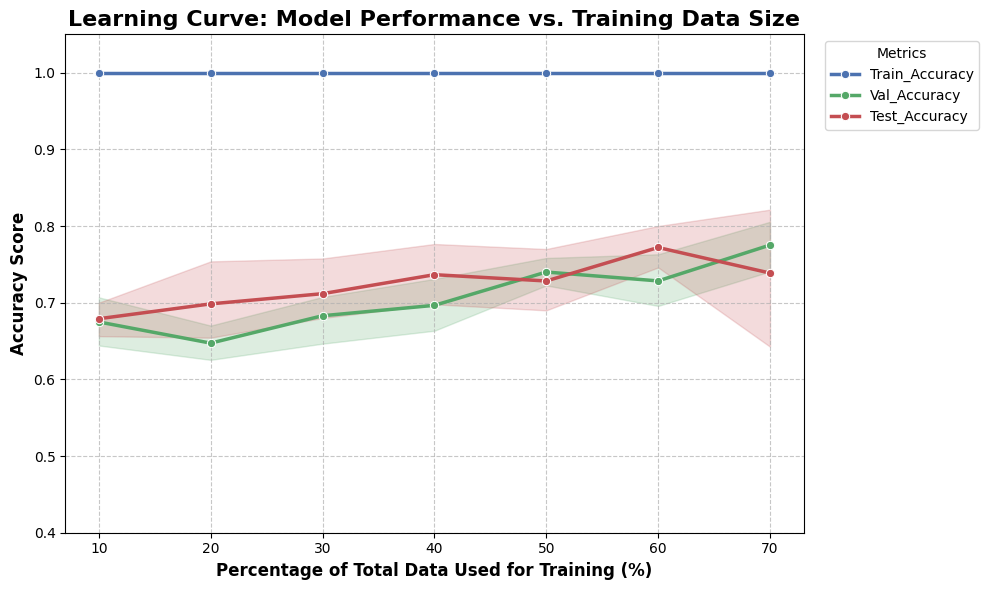

In [6]:
plot_learning_curve(master_lc_df)

Now that RT and logS have successfully been added to the training model, let's see if adding another parameter helps predict better: the **matrix ID**. Since there's only 7 different types of matrix IDs, I recommend using one-hot coding again. We can't use our current cleaning_array functions because this time we need the repeating data (they only differ by Matrix ID).

In [5]:
raw_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx')
print(raw_df['Matrix ID Name'].value_counts())


Matrix ID Name
matrix ID BlueBird 1    151
matrix ID PFP 1         151
matrix ID PolarTec 1    151
matrix ID RP18 1        151
matrix ID RP18 2        151
matrix ID Sphinx 1      151
matrix ID Sphinx 2      151
Name: count, dtype: int64


In [6]:
print(raw_df.columns.tolist())

['Column', 'Method', 'Sample Name', 'CAS ', 'RT', 'Signal', 'Matrix ID Name', 'MeOH', 'ACN', 'DMSO', 'DCM', 'CHCl3', 'solute_smiles']


In [6]:
clean_df = scrub(raw_df, smiles_col='solute_smiles')
"""sol_matrix = solubility_file_matrix(clean_df, NMR_SOLVENTS)"""
sol_matrix= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')

🧹 Starting cleanup. Original rows: 1057
   -> Dropped 1 rows containing invalid or missing SMILES.
✅ Cleaned row count: 1056


[11:36:20] SMILES Parse Error: syntax error while parsing: Did
[11:36:20] SMILES Parse Error: check for mistakes around position 1:
[11:36:20] Did
[11:36:20] ^
[11:36:20] SMILES Parse Error: Failed parsing SMILES 'Did' for input: 'Did'


In [7]:
print(sol_matrix.shape)
print(final_working_df.columns.tolist())

(1056, 18)
['Column', 'Method', 'Sample Name', 'CAS ', 'RT', 'Signal', 'Matrix ID Name', 'MeOH', 'ACN', 'DMSO', 'DCM', 'CHCl3', 'solute_smiles', 'predicted_logS_MeOH', 'predicted_logS_ACN', 'predicted_logS_DMSO', 'predicted_logS_DCM', 'predicted_logS_CHCl3']


In [7]:
final_working_df = add_logs_to_df(clean_df, sol_matrix, NMR_SOLVENTS)
print(final_working_df.shape)
print(final_working_df.columns.tolist())

Successfully added 5 exact logS columns
(1056, 18)
['Column', 'Method', 'Sample Name', 'CAS ', 'RT', 'Signal', 'Matrix ID Name', 'MeOH', 'ACN', 'DMSO', 'DCM', 'CHCl3', 'solute_smiles', 'predicted_logS_MeOH', 'predicted_logS_ACN', 'predicted_logS_DMSO', 'predicted_logS_DCM', 'predicted_logS_CHCl3']


In [8]:
print("Gathering data for all solvents...")
all_dfs_v3 = []

for sol in NMR_SOLVENTS.keys():
    # since we are using cleaned_df, we just look for 'MeOH', 'ACN', etc.
    if sol in clean_df.columns:
        df_temp = generate_ml_file_with_logs(final_working_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs_v3.append(df_temp)
        print(f"Added {sol}: {len(df_temp)} rows")
    else:
        print(f"Skipped {sol}: Column not found")

# sticking everything together
mega_df_v3 = pd.concat(all_dfs_v3, ignore_index=True)
print(f"DataFrame built! Total Rows: {len(mega_df_v3)}")

Gathering data for all solvents...


[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerator
[11:36:28] DEPRECATION WARNING: please use MorganGenerat

Added MeOH: 1056 rows


[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerator
[11:36:33] DEPRECATION WARNING: please use MorganGenerat

Added ACN: 1056 rows


[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerator
[11:36:37] DEPRECATION WARNING: please use MorganGenerat

Added DMSO: 1056 rows


[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerator
[11:36:42] DEPRECATION WARNING: please use MorganGenerat

Added DCM: 1056 rows


[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerator
[11:36:46] DEPRECATION WARNING: please use MorganGenerat

Added CHCl3: 1056 rows
DataFrame built! Total Rows: 5280


[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerator
[11:36:50] DEPRECATION WARNING: please use MorganGenerat

In [20]:
print(mega_df_v3.columns.tolist())
print(mega_df_v3.shape)

['Sample Fingerprint', 'RT', 'logS', 'Solvent', 'Soluble', 'solute_smiles']
(5280, 6)


In [8]:
print("raw_df columns:", raw_df.columns.tolist())
print("mega_df_v3 columns:", mega_df_v3.columns.tolist())

raw_df columns: ['Column', 'Method', 'Sample Name', 'CAS ', 'RT', 'Signal', 'Matrix ID Name', 'MeOH', 'ACN', 'DMSO', 'DCM', 'CHCl3', 'solute_smiles']
mega_df_v3 columns: ['Sample Fingerprint', 'RT', 'logS', 'Solvent', 'Soluble', 'SMILES']


In [9]:
mega_df_v3 = mega_df_v3.rename(columns={'SMILES': 'solute_smiles', 'SMILES ': 'solute_smiles'})
mega_df_v4 = add_matrix_id_to_df(mega_df_v3, raw_df, 'Matrix ID Name')

One-Hot Encoding the 'Matrix ID Name' column...
   Successfully packed 7 matrices: ['matrix ID BlueBird 1' 'matrix ID PFP 1' 'matrix ID PolarTec 1'
 'matrix ID RP18 1' 'matrix ID RP18 2' 'matrix ID Sphinx 1'
 'matrix ID Sphinx 2']
   -> Example array looks like: [1 0 0 0 0 0 0]


In [10]:
print(f"Rows before merge (v3): {len(mega_df_v3)}")
print(f"Rows after merge  (v4): {len(mega_df_v4)}")
print(mega_df_v4.columns.tolist())

Rows before merge (v3): 5280
Rows after merge  (v4): 36930
['Sample Fingerprint', 'RT', 'logS', 'Solvent', 'Soluble', 'solute_smiles', 'Matrix_Packed_Array']


Okay now that we know for sure that the matrix ID is included, lets train the model.

In [10]:
mega_df_v4 = mega_df_v4.rename(columns={'solute_smiles': 'SMILES'})

In [12]:
mega_df_v5 = compress_fingerprints_pca(mega_df_v4, fp_col_name='Sample Fingerprint', variance_to_keep=0.95)

Compressing 'Sample Fingerprint' using PCA...
-> Target: Keep 95.0% of the original chemical information.
   Compression Complete!
   -> Original Dimensions: 2048 bits
   -> New Dimensions:      114 dense features


In [17]:
percentages_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
all_learning_curve_results = []

for pct in percentages_to_test:
    # Call the function we just built
    df_step = run_data_fraction(mega_df_v5, train_percent_of_total=pct)
    
    # Add the results to our list
    all_learning_curve_results.append(df_step)

# Glue everything together into one master DataFrame for plotting later
master_lc_df = pd.concat(all_learning_curve_results, ignore_index=True)

print("\nAll learning curve steps complete and concatenated")


Running Learning Curve Step: 10% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_10pct.txt

Running Learning Curve Step: 20% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_20pct.txt

Running Learning Curve Step: 30% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_30pct.txt

Running Learning Curve Step: 40% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_40pct.txt

Running Learning Curve Step: 50% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/dynamic_learning_curve_50pct.txt

Running Learning Curve Step: 60% of total data...
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/learning_cur

Generating Learning Curve Plot...
-> Plot successfully saved to /Users/arthurbenard/Project 1B/src/analysis/learning_curve_results/Learning_Curve_Plot.png


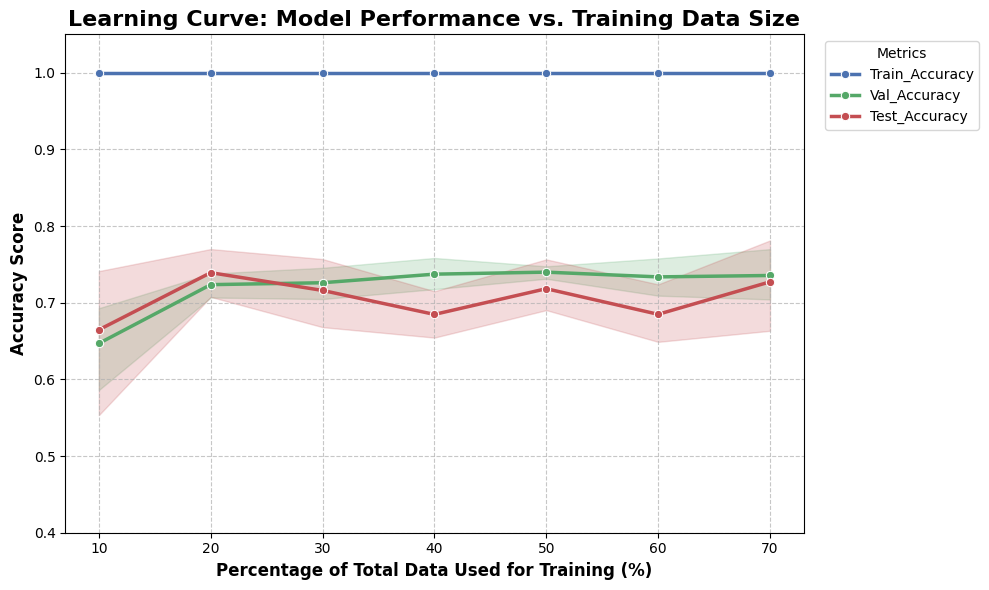

In [18]:
plot_learning_curve(master_lc_df)

It has been suggested that the Ai is "lazy" and attributes 'Soluble' status blindly, primarly because the set list is imbalanced. This has to be checked, and if so it may be possible to fix it with class_weight='balanced'. Let's see.

In [ ]:
# Let's check the ratio of Soluble (1) vs Insoluble (0)
print(mega_df_v5['Soluble'].value_counts(normalize=True) * 100)
print("\nRaw counts:")
print(mega_df_v5['Soluble'].value_counts())

Soluble
1    66.969943
0    33.030057
Name: proportion, dtype: float64

Raw counts:
Soluble
1    24732
0    12198
Name: count, dtype: int64


In [13]:
raw_col_name = 'Sample Fingerprint' 

print(f"Extracting raw 2048-bit fingerprints from '{raw_col_name}'...")

# Stack all the tiny arrays into one giant 2D matrix (just like for PCA)
X_raw = np.vstack(mega_df_v4[raw_col_name].values)
y = mega_df_v4['Soluble'].values.astype(int)

# Split it into Train and Test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, 
    y, 
    test_size=0.20, 
    random_state=56
)

Extracting raw 2048-bit fingerprints from 'Sample Fingerprint'...


In [13]:
k_values_to_test = [50, 100, 200, 500, 1000, 2048] # 2048 represents using ALL bits

# Lists to store our results for the plot
train_accuracies = []
test_accuracies = []

print(" Starting SelectKBest Optimization Loop...\n")

for k in k_values_to_test:
    print(f"Testing k={k} best features...")
    
    # --- A. FEATURE SELECTION ---
    if k == 2048:
        # If 2048, just use the raw data without cutting anything
        X_train_k = X_train_raw
        X_test_k = X_test_raw
    else:
        # chi2 is the perfect statistical test for 0s and 1s
        selector = SelectKBest(score_func=chi2, k=k)
        # fit_transform learns which bits are best from the Train set AND cuts it down
        X_train_k = selector.fit_transform(X_train_raw, y_train)
        # transform just cuts the Test set down using the same rules
        X_test_k = selector.transform(X_test_raw)
    
    # --- B. TRAIN THE MODEL ---
    # We keep class_weight='balanced' to handle your 67/33 imbalance!
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_train_k, y_train)
    
    # --- C. SCORE THE MODEL ---
    # We want to see how well it does on BOTH sets to check for overfitting
    train_score = accuracy_score(y_train, rf.predict(X_train_k))
    test_score = accuracy_score(y_test, rf.predict(X_test_k))
    
    train_accuracies.append(train_score)
    test_accuracies.append(test_score)


# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values_to_test, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(k_values_to_test, test_accuracies, label='Testing Accuracy', marker='s', color='orange')

plt.title("SelectKBest Optimization: Overfitting Check")
plt.xlabel("Number of Fingerprint Bits Kept (k)")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

 Starting SelectKBest Optimization Loop...

Testing k=50 best features...
Testing k=100 best features...
Testing k=200 best features...
Testing k=500 best features...


KeyboardInterrupt: 

I think it's time to switch up models. We're going to test out XGBoost, which builds simple decision trees and stacks them to correct the specific residual errors of the previous ones. It also supposedly faster.

In [13]:
print("Stitching PCA, Solvent, and Matrix features together...")

# Extract the three separate arrays
X_pca = np.vstack(mega_df_v5['Sample Fingerprint'].values)
X_solvent = np.vstack(mega_df_v5['Solvent'].values)
X_matrix = np.vstack(mega_df_v5['Matrix_Packed_Array'].values)

# Glue them side-by-side using hstack (horizontal stack)
X_combined = np.hstack((X_pca, X_solvent, X_matrix))
y = mega_df_v5['Soluble'].values.astype(int)

print(f"New feature shape (molecules + solvent + matrix): {X_combined.shape}")

# Split the new fully-loaded dataset
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, 
    y, 
    test_size=0.20, 
    random_state=56
)

Stitching PCA, Solvent, and Matrix features together...
New feature shape (molecules + solvent + matrix): (36930, 126)
Splitting data...


In [23]:
print("Initializing XGBoost model...")
xgb_model = xgboost.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

print("Training the model on PCA features...")
xgb_model.fit(X_train, y_train)

print("Testing the model...")
y_pred = xgb_model.predict(X_test)

Initializing XGBoost model...
Training the model on PCA features...
Testing the model...


In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Breakdown:")
print(classification_report(y_test, y_pred))


--- RESULTS ---
Overall Accuracy: 98.81%

Detailed Breakdown:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2440
           1       0.99      0.99      0.99      4946

    accuracy                           0.99      7386
   macro avg       0.99      0.99      0.99      7386
weighted avg       0.99      0.99      0.99      7386



In [25]:
# Calculate the matrix using your test data and predictions
cm = confusion_matrix(y_test, y_pred)

# Break down the grid into the four categories
true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

print("--- CONFUSION MATRIX (RAW NUMBERS) ---")
print(f"Correctly predicted Insoluble (True Negatives): {true_negatives}")
print(f"Correctly predicted Soluble (True Positives):   {true_positives}")
print("-" * 45)
print(f"MISTAKE - Predicted Soluble, actually Insoluble (False Positives): {false_positives}")
print(f"MISTAKE - Predicted Insoluble, actually Soluble (False Negatives): {false_negatives}")

--- CONFUSION MATRIX (RAW NUMBERS) ---
Correctly predicted Insoluble (True Negatives): 2393
Correctly predicted Soluble (True Positives):   4905
---------------------------------------------
MISTAKE - Predicted Soluble, actually Insoluble (False Positives): 47
MISTAKE - Predicted Insoluble, actually Soluble (False Negatives): 41


In [19]:
print("Total rows:", len(mega_df_v5))

# The .astype(str) turns the arrays into text temporarily so Pandas can actually compare them!
unique_count = len(mega_df_v5.astype(str).drop_duplicates())
print("Number of perfectly unique rows:", unique_count)

Total rows: 36930
Number of perfectly unique rows: 33710


In [21]:
# Let's see what your Matrix and Solvent columns look like
print("Solvent example:", mega_df_v4['Solvent'].iloc[0])
print("Matrix example:", mega_df_v4['Matrix_Packed_Array'].iloc[0])
print("Matrix type:", type(mega_df_v4['Matrix_Packed_Array'].iloc[0]))

Solvent example: [1 0 0 0 0]
Matrix example: [1 0 0 0 0 0 0]
Matrix type: <class 'numpy.ndarray'>


Establishing a learning curve for this model, training on PCA/Solvent/Matrix ID/ Solubility

In [16]:
random_seeds = [42, 123, 999]

all_train_scores = []
all_test_scores = []

for seed in random_seeds:
    # Set up the exact same XGBoost model
    xgb_model = xgboost.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=seed,
        eval_metric='logloss'
    )

    # Generate the learning curve data with implemented learning_curve function (of course)
    # We use X_train and y_train so our actual test set remains completely unseen
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=xgb_model,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.1, 1.0, 7), # 10 steps from 10% to 70% of data
        cv=5,                                  # 5-fold cross-validation for accuracy
        scoring='accuracy',
        n_jobs=-1                              
    )
    all_train_scores.append(train_scores)
    all_test_scores.append(test_scores)


final_train_scores = np.mean(all_train_scores, axis=0)
final_test_scores = np.mean(all_test_scores, axis=0)

# Calculate the averages and standard deviations for the plot
train_mean = np.mean(final_train_scores, axis=1)
train_std = np.std(final_train_scores, axis=1)
test_mean = np.mean(final_test_scores, axis=1)
test_std = np.std(final_test_scores, axis=1)


Plotting the results...


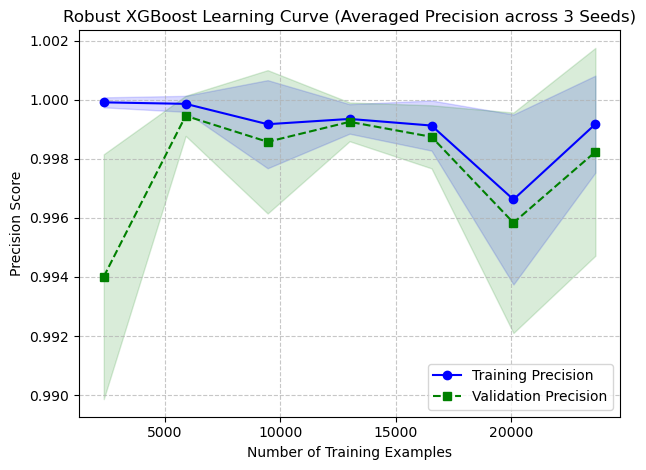

In [ ]:
print("Plotting the results...")

plt.plot(train_sizes, train_mean, color='blue', marker='o', label='Training Precision')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', marker='s', linestyle='--', label='Validation Precision')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.title('XGBoost Learning Curve (Averaged Precision across 3 Seeds)')
plt.xlabel('Number of Training Examples')
plt.ylabel('Precision Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Leander gave me some important information: PCA calculates correlation between columns and erases the ones that have relatively high ones, which can delete some important information. There's also a matching problem when the model will have to predict molecules with higher dimensions. So we're gonna switch to Skbest.

In [13]:
print(" Extracting raw features and SMILES groups...")
X_fp_raw = np.vstack(mega_df_v4['Sample Fingerprint'].values)
X_solvent = np.vstack(mega_df_v4['Solvent'].values)
X_matrix = np.vstack(mega_df_v4['Matrix_Packed_Array'].values)
y = mega_df_v4['Soluble'].values.astype(int)
groups = mega_df_v4['SMILES'].values  # We need the SMILES to group them!

print(" SPLIT: Keeping molecules completely grouped...") #leak proof
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=68)
train_idx, test_idx = next(gss.split(X_fp_raw, y, groups))

# Split all arrays using the safe grouped indices
X_fp_train, X_fp_test = X_fp_raw[train_idx], X_fp_raw[test_idx]
X_sol_train, X_sol_test = X_solvent[train_idx], X_solvent[test_idx]
X_mat_train, X_mat_test = X_matrix[train_idx], X_matrix[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx] # We save this for the learning curve later

 Extracting raw features and SMILES groups...
 SPLIT: Keeping molecules completely grouped...


In [23]:
# SKBest fitting here
print(" Fitting SelectKBest on train data...")
k_best = SelectKBest(score_func=chi2, k=200)

# fit_transform on train (it learns the best bits here)
X_fp_train_best = k_best.fit_transform(X_fp_train, y_train)

# transform ONLY on test (it applies the bits it learned without peeking)
X_fp_test_best = k_best.transform(X_fp_test)

print(" Gluing the safe features together...")
X_train_final = np.hstack((X_fp_train_best, X_sol_train, X_mat_train))
X_test_final = np.hstack((X_fp_test_best, X_sol_test, X_mat_test))

 Fitting SelectKBest on train data...
 Gluing the safe features together...


In [24]:
xgb_model = xgboost.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=54,
    eval_metric='logloss'
)

xgb_model.fit(X_train_final, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [25]:
print(" Testing the model...")
y_pred = xgb_model.predict(X_test_final)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- SELECT K BEST RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

 Testing the model...

--- SELECT K BEST RESULTS ---
Overall Accuracy: 72.26%

              precision    recall  f1-score   support

           0       0.48      0.33      0.39      2058
           1       0.78      0.87      0.82      5537

    accuracy                           0.72      7595
   macro avg       0.63      0.60      0.61      7595
weighted avg       0.70      0.72      0.70      7595



Lets establish two learning curves: one that changes the trainin data set and one that modifies the amount of k selectors.

Starting Multi-Seed, Zero-Leakage Dual Analysis...

--- Running Pipeline for Random Seed: 42 ---
  -> Calculating Data Size Curve (k=100)...
  -> Calculating K-Features Validation Curve...

--- Running Pipeline for Random Seed: 123 ---
  -> Calculating Data Size Curve (k=100)...
  -> Calculating K-Features Validation Curve...

--- Running Pipeline for Random Seed: 999 ---
  -> Calculating Data Size Curve (k=100)...
  -> Calculating K-Features Validation Curve...

All seeds complete! Averaging data and building plots...


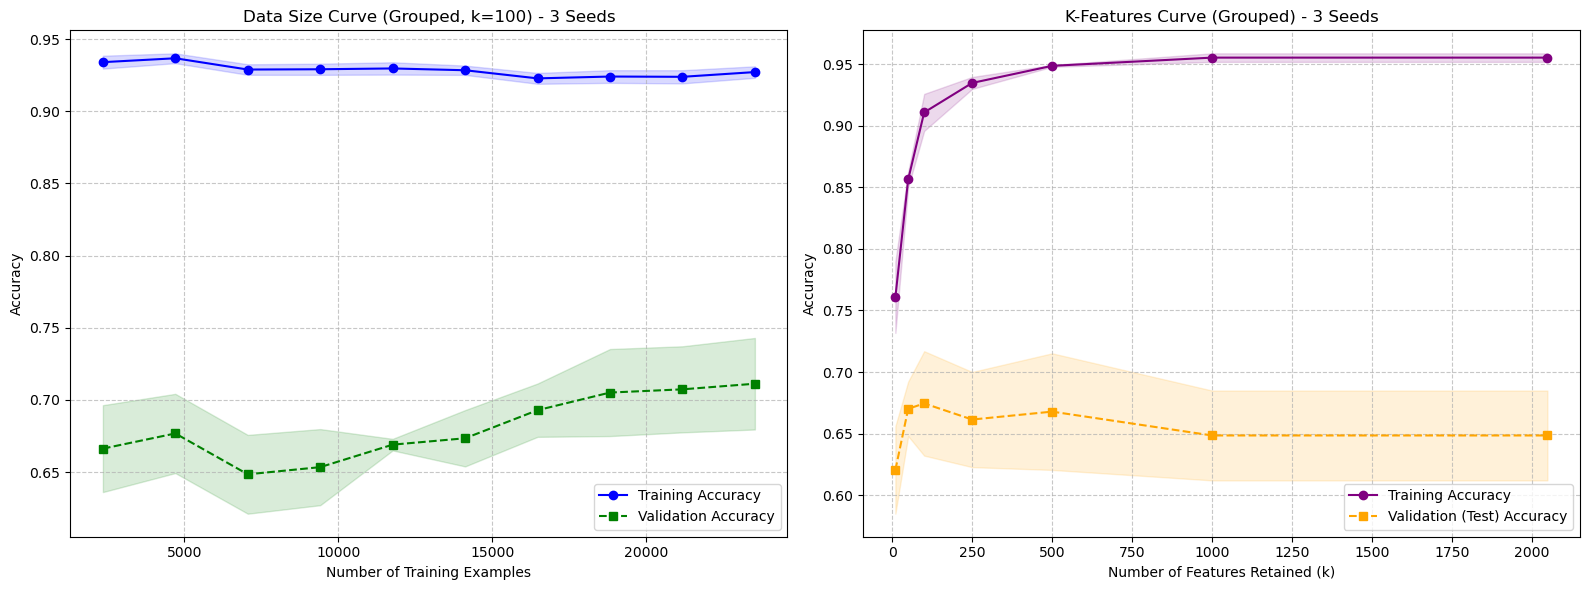

In [12]:
learning_curve_trainsize_kselectors(mega_df_v4)

Next step is running similar ablation studies as before but with XGBoost.

In [21]:
df_results = run_ablation_xgboost(mega_df_v4, None)

  AVAILABLE FEATURES TO REMOVE:
  - Sample Fingerprint
  - RT
  - logS
  - Solvent
  - Matrix_Packed_Array
  - None (Keep all features)

Removing [Solvent] from model...
Matrix shape after removal: (36930, 2057)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_XGBOOST_no_Solvent.txt



In [22]:
df_none = run_ablation_xgboost(mega_df_v4, features_to_remove='None')
df_rt = run_ablation_xgboost(mega_df_v4, features_to_remove='RT')
df_logs = run_ablation_xgboost(mega_df_v4, features_to_remove='logS')
df_sol = run_ablation_xgboost(mega_df_v4, features_to_remove='Solvent')
df_mid = run_ablation_xgboost(mega_df_v4, features_to_remove='Matrix_Packed_Array')
df_fp = run_ablation_xgboost(mega_df_v4, features_to_remove='Sample Fingerprint')
df_fp_rt = run_ablation_xgboost(mega_df_v4, features_to_remove='Sample Fingerprint, RT')
df_rt_logs = run_ablation_xgboost(mega_df_v4, features_to_remove='logS, RT')
df_rt_mid = run_ablation_xgboost(mega_df_v4, features_to_remove='Matrix_Packed_Array, RT')



Removing [None] from model...
Matrix shape after removal: (36930, 2062)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_XGBOOST_no_None.txt


Removing [RT] from model...
Matrix shape after removal: (36930, 2061)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_XGBOOST_no_RT.txt


Removing [logS] from model...
Matrix shape after removal: (36930, 2061)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_XGBOOST_no_logS.txt


Removing [Solvent] from model...
Matrix shape after removal: (36930, 2057)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_XGBOOST_no_Solvent.txt


Removing [Matrix_Packed_Array] from model...
Matrix shape after removal: (36930, 2055)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_XGBOOST_no_Matrix_Packed_Array.txt


Re

Plot successfully saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/Ablation_SuperPlot.png


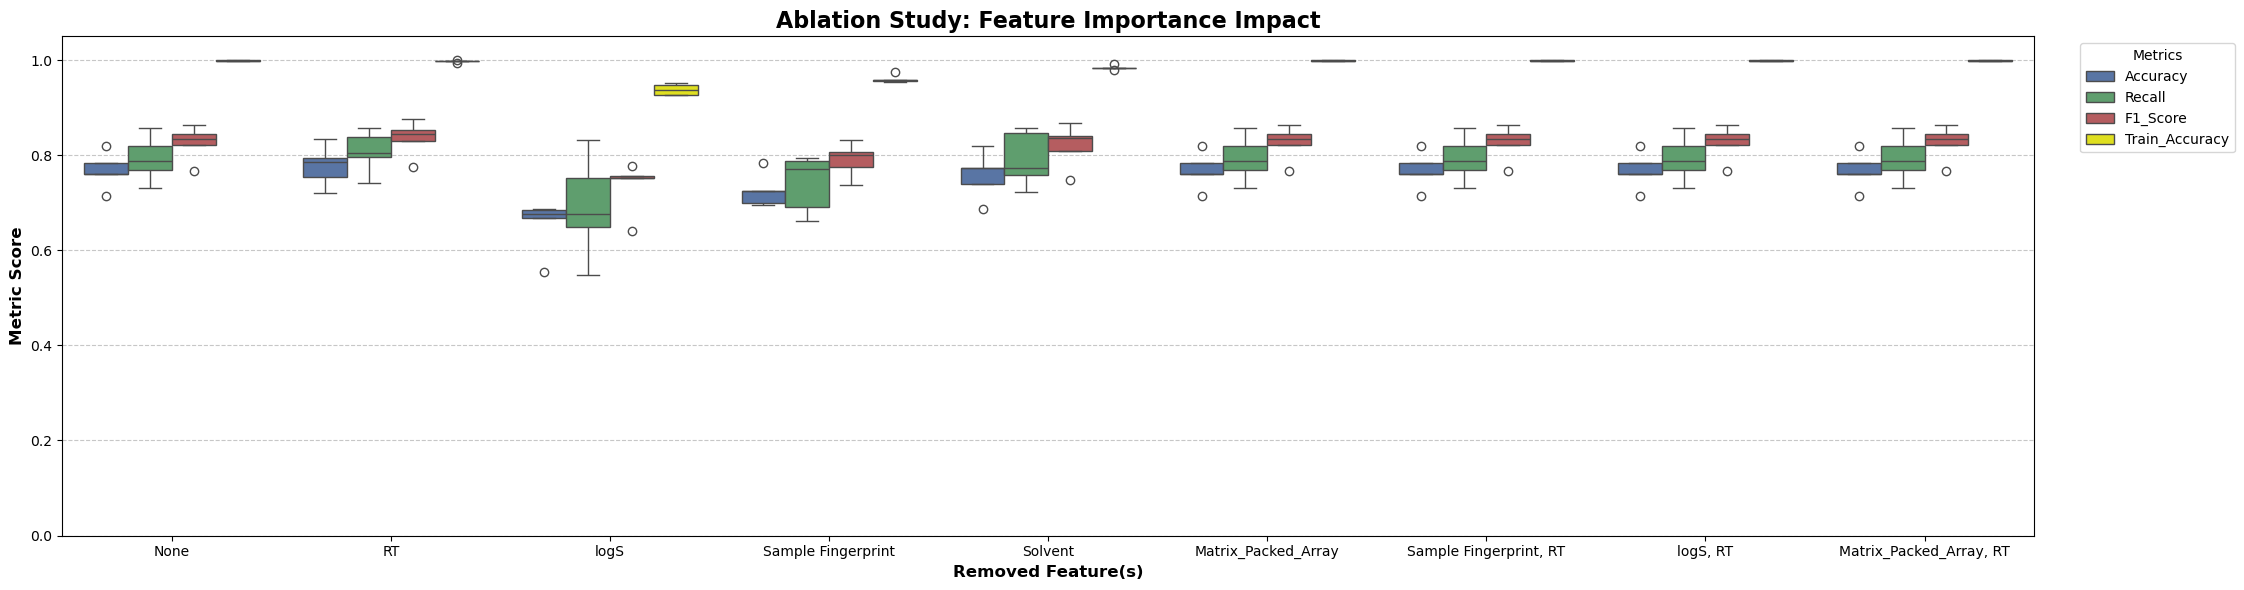

In [23]:
# Glue them together into one massive DataFrame
all_results_df = pd.concat([df_none, df_rt, df_logs, df_fp,  df_sol, df_mid, df_fp_rt, df_rt_logs, df_rt_mid], ignore_index=True)

plot_comparison(all_results_df)

The aime here is to improve XGBoost. We're going to add more Descriptors to the dataframe and see how it improves and which improves it better.

This cell will create three new columns, containing the following descriptors: Octanol-Water Partition Coefficient, Topological Polar Surface Area, Molecular Weight, H-bond donors and acceptors. 

In [12]:
df_desc = mega_df_v4.copy()
df_desc[['MolLogP', 'TPSA', 'MolWt' , 'NumHDonors', 'NumHAcceptors']] = df_desc['SMILES'].apply(calculate_descriptors)
print("Extraction complete")
print(df_desc[['SMILES', 'MolLogP', 'TPSA', 'MolWt', 'NumHDonors', 'NumHAcceptors']].head())

Extraction complete
              SMILES  MolLogP  TPSA    MolWt  NumHDonors  NumHAcceptors
0  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0
1  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0
2  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0
3  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0
4  CC(C1=CC=CC=C1)Br   3.1425   0.0  185.064         0.0            0.0


In [13]:
df_desc[df_desc['TPSA'] == 0.0][['SMILES', 'TPSA', 'Soluble', 'NumHDonors', 'NumHAcceptors']].head(10)

,SMILES,TPSA,Soluble,NumHDonors,NumHAcceptors
0,CC(C1=CC=CC=C1)Br,0.0,1,0.0,0.0
1,CC(C1=CC=CC=C1)Br,0.0,1,0.0,0.0
2,CC(C1=CC=CC=C1)Br,0.0,1,0.0,0.0
3,CC(C1=CC=CC=C1)Br,0.0,1,0.0,0.0
4,CC(C1=CC=CC=C1)Br,0.0,1,0.0,0.0
5,CC(C1=CC=CC=C1)Br,0.0,1,0.0,0.0
6,CC(C1=CC=CC=C1)Br,0.0,1,0.0,0.0
84,C1=C(C=C(C=C1C(F)(F)F)Br)C(F)(F)F,0.0,1,0.0,0.0
85,C1=C(C=C(C=C1C(F)(F)F)Br)C(F)(F)F,0.0,1,0.0,0.0
86,C1=C(C=C(C=C1C(F)(F)F)Br)C(F)(F)F,0.0,1,0.0,0.0


In [14]:
df_desc[df_desc['NumHDonors'] > 0.0]['NumHDonors'].describe()

count    19600.000000
mean         1.662500
std          0.805374
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: NumHDonors, dtype: float64

This new dataframe will serve as the base for the comparison step. We're going to let the accuracies compete based on which descriptors were used to train the model.

Apparently scaling is necessary to avoid the model to freak out when it sees big values (e.g MW) compared to binary values, risking to judge the descriptor as much more important. StandardScaler squashes the values into more "manageable" ones (uses z-score formula).

In [16]:
tournament_results = run_descriptor_competition(df_desc, 200)

 Preparing Data, Splitting, and Scaling (Leakage-Free)...
 -> Calculated scale_pos_weight: 0.45
 Running the Descriptor Tournament...

             TOURNAMENT RESULTS                   
                                       Experiment  Accuracy  Precision
                     1. Baseline (No Descriptors)  0.774194   0.743590
                            2. Baseline + MolLogP  0.722581   0.696000
                               3. Baseline + TPSA  0.735484   0.762887
                              4. Baseline + MolWt  0.690323   0.680328
                        5. Baseline + LogP + TPSA  0.729032   0.755102
                       6. Baseline + LogP + MolWt  0.683871   0.666667
                       7. Baseline + TPSA + MolWt  0.767742   0.769231
       8. Baseline + H-Bonds (Donors & Acceptors)  0.761290   0.743363
9. Baseline + TPSA + H-Bonds (Donors & Acceptors)  0.735484   0.752475
                                        10. All 5  0.729032   0.727273


In [17]:
tournament_results = run_descriptor_competition(df_desc, 100)

 Preparing Data, Splitting, and Scaling (Leakage-Free)...
 -> Calculated scale_pos_weight: 0.45
 Running the Descriptor Tournament...

             TOURNAMENT RESULTS                   
                                       Experiment  Accuracy  Precision
                     1. Baseline (No Descriptors)  0.683871   0.704762
                            2. Baseline + MolLogP  0.683871   0.680672
                               3. Baseline + TPSA  0.670968   0.720430
                              4. Baseline + MolWt  0.664516   0.700000
                        5. Baseline + LogP + TPSA  0.664516   0.717391
                       6. Baseline + LogP + MolWt  0.638710   0.655172
                       7. Baseline + TPSA + MolWt  0.709677   0.728155
       8. Baseline + H-Bonds (Donors & Acceptors)  0.690323   0.689655
9. Baseline + TPSA + H-Bonds (Donors & Acceptors)  0.683871   0.726316
                                        10. All 5  0.709677   0.711712


After testing these parameters, it seems we'll keep working with the baseline while adding TPSA and molecular weight. Now what is left is maxing out the hyperparameters. 

In [ ]:
df_desc = mega_df_v4.copy()
df_desc[['TPSA', 'MolWt']] = df_desc['SMILES'].apply(calculate_descriptors)
print("Extraction complete")